# CUAD dataset pre-processing for BERT classification

In [1]:
import pandas as pd
import re
import ast

Download data from https://huggingface.co/datasets/theatticusproject/cuad/tree/main/CUAD_v1 and put them on ../data/

In [3]:
df = pd.read_csv('../data/CUAD_v1/master_clauses.csv')

## Class selection

Let's drop columns related to question-answering 

In [47]:
col_to_drop = df.columns.map(lambda x: re.match(r'.*Answer', x) == None)

In [48]:
df = df[df.columns[col_to_drop]]

In [50]:
df.drop(columns=['Filename', 'Document Name', 'Agreement Date', 'Effective Date', 'Expiration Date'], inplace=True)

Transforming the dataset into the form: Text, Clause

In [51]:
df = df.melt(var_name="Clause", value_name="Text")

Dropping empty paragraphs

In [52]:
df[df['Text'] == '[]']

df.drop(df[df['Text'] == '[]'].index, inplace=True)

In [53]:
import numpy as np
np.where(df['Text'].isna())

(array([], dtype=int64),)

### Selecting relevant classes

In [ ]:
classes = ['Governing Law', 'Termination For Convenience', 'Renewal Term', 'Cap On Liability', 'Liquidated Damages', 'Non-Compete', 'Exclusivity', 'Audit Rights', 'Ip Ownership Assignment']

def check_class(x:str):
    if x not in classes:
        return "Other"
    else:
        return x

In [59]:
df['Clause'] = df['Clause'].apply(lambda x: check_class(x))

In [60]:
df['Clause'].value_counts()

Clause
Other                          3150
Governing Law                   437
Cap On Liability                275
Audit Rights                    214
Termination For Convenience     183
Exclusivity                     180
Renewal Term                    176
Ip Ownership Assignment         124
Non-Compete                     119
Liquidated Damages               61
Name: count, dtype: int64

## Deserializing string lists using ast

In [65]:
l = []

for (clause, text) in zip(df['Clause'], df['Text']):
    for item in ast.literal_eval(text):
        if len(item.split()) > 10:
            l.append((clause, item))
            
formatted_data = pd.DataFrame(l, columns=['Clause', 'Text'])

In [67]:
formatted_data

,Clause,Text
0,Other,"collectively, Lender, Endorser, and Fitness ar..."
1,Other,"Skype, Online BVI and the Company may be refer..."
2,Other,Stryker and Conformis are collectively referre...
3,Other,Hydraspin and Distributor are sometimes herein...
4,Other,"Wade Enterprises, Athlete and together with Na..."
...,...,...
8753,Other,"Franchisor, along with its successors and assi..."
8754,Other,Lessor and Lessee expressly agree that Franchi...
8755,Other,"Except as expressly provided in Section 8, thi..."
8756,Other,"Changepoint, Inc. (""Changepoint"") shall be a ..."


In [68]:
formatted_data['Clause'].value_counts()

Clause
Other                          5625
Cap On Liability                631
Audit Rights                    609
Governing Law                   455
Exclusivity                     385
Ip Ownership Assignment         295
Non-Compete                     225
Termination For Convenience     221
Renewal Term                    199
Liquidated Damages              113
Name: count, dtype: int64

## Undersampling class "Other"

In [69]:
oth_class = formatted_data[formatted_data['Clause'] == 'Other']

In [70]:
sampled = formatted_data.drop(oth_class.sample(5000).index)

<Axes: xlabel='Clause'>

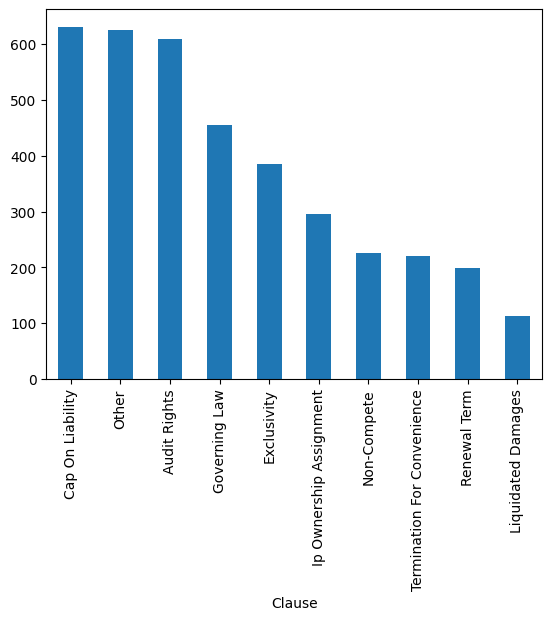

In [71]:
sampled['Clause'].value_counts().plot(kind='bar')

In [72]:
sampled['Clause'].value_counts().keys()

Index(['Cap On Liability', 'Other', 'Audit Rights', 'Governing Law',
       'Exclusivity', 'Ip Ownership Assignment', 'Non-Compete',
       'Termination For Convenience', 'Renewal Term', 'Liquidated Damages'],
      dtype='str', name='Clause')

In [73]:
i = 0

for c in sampled['Clause'].value_counts().keys():
    sampled.replace(c, i, inplace=True)
    i = i+1

In [74]:
sampled['Clause'].value_counts()

Clause
0    631
1    625
2    609
3    455
4    385
5    295
6    225
7    221
8    199
9    113
Name: count, dtype: int64

In [75]:
sampled.to_csv('../data/cuad_cls.csv', index=False)